# Notebook Purpose

Exploratory data analysis of Instacart orders to understand user behavior, reorder patterns, and product concentration.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load data
orders = pd.read_csv('../data/raw/orders.csv')
order_products_prior = pd.read_csv('../data/raw/order_products__prior.csv')
order_products_train = pd.read_csv('../data/raw/order_products__train.csv')
products = pd.read_csv('../data/raw/products.csv')
aisles = pd.read_csv('../data/raw/aisles.csv')
departments = pd.read_csv('../data/raw/departments.csv')

print(f"Orders: {orders.shape}")
print(f"Prior order products: {order_products_prior.shape}")
print(f"Products: {products.shape}")


Orders: (3421083, 7)
Prior order products: (32434489, 4)
Products: (49688, 4)


In [8]:
print(orders.head())


   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  


In [9]:
print(order_products_prior.head())


   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0


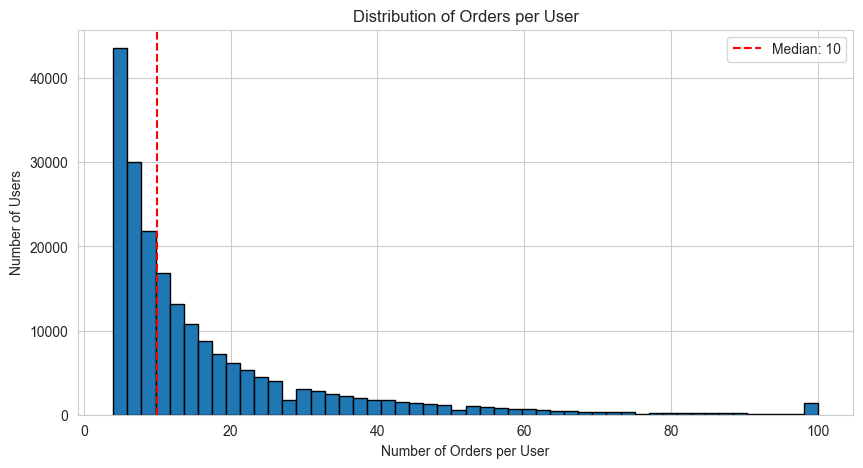

Average orders per user: 16.59
Median orders per user: 10
Max orders per user: 100
Total users: 206,209
Users with <5 orders: 11.63%


In [21]:
# 1. How many orders does each user have?
user_order_counts = orders.groupby('user_id')['order_id'].count()

total_users = len(user_order_counts)

users_lt_5 = (user_order_counts < 5).sum()
pct_users_lt_5 = users_lt_5 / total_users * 100

plt.figure(figsize=(10, 5))
plt.hist(user_order_counts, bins=50, edgecolor='black')
plt.xlabel('Number of Orders per User')
plt.ylabel('Number of Users')
plt.title('Distribution of Orders per User')
plt.axvline(user_order_counts.median(), color='red', linestyle='--', 
            label=f'Median: {user_order_counts.median():.0f}')
plt.legend()
plt.show()

print(f"Average orders per user: {user_order_counts.mean():.2f}")
print(f"Median orders per user: {user_order_counts.median():.0f}")
print(f"Max orders per user: {user_order_counts.max()}")

print(f"Total users: {total_users:,}")
print(f"Users with <5 orders: {pct_users_lt_5:.2f}%")


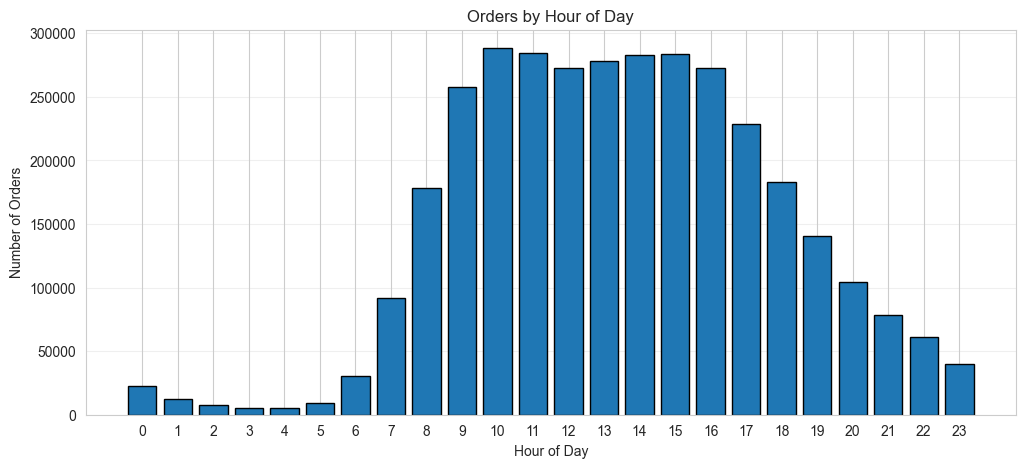

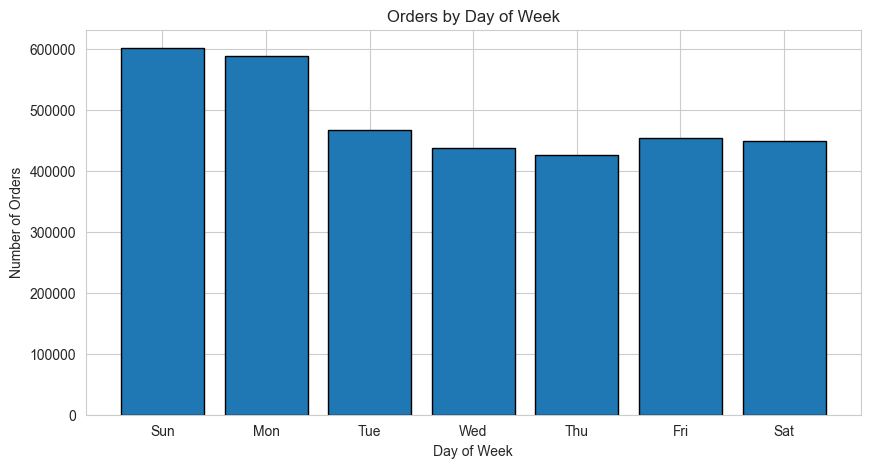

Peak shopping hour: 10:00 with 288,418 orders
Peak shopping day: Sun with 600,905 orders


In [22]:
# 2. When do users shop?
order_hour_dist = orders['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(order_hour_dist.index, order_hour_dist.values, edgecolor='black')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Orders by Hour of Day')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.show()

# Which day of week do users shop?
order_dow_dist = orders['order_dow'].value_counts().sort_index()
dow_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

plt.figure(figsize=(10, 5))
plt.bar(range(7), order_dow_dist.values, tick_label=dow_names, edgecolor='black')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.title('Orders by Day of Week')
plt.show()

# Peak hours
peak_hour = order_hour_dist.idxmax()
peak_hour_orders = order_hour_dist.max()

# Peak day of the week
peak_dow = order_dow_dist.idxmax()
peak_dow_orders = order_dow_dist.max()

print(f"Peak shopping hour: {peak_hour}:00 with {peak_hour_orders:,} orders")
print(f"Peak shopping day: {dow_names[peak_dow]} with {peak_dow_orders:,} orders")


True peak time: Mon 10:00 with 55,671 orders


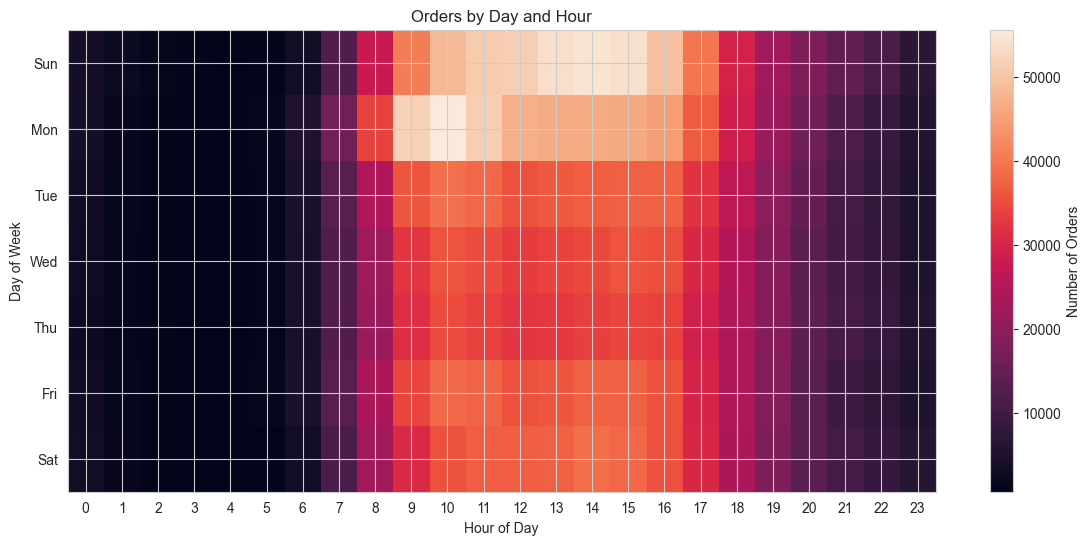

In [25]:
day_hour_counts = (
    orders
    .groupby(['order_dow', 'order_hour_of_day'])
    .size()
    .reset_index(name='order_count')
)

peak_row = day_hour_counts.loc[day_hour_counts['order_count'].idxmax()]

peak_day = peak_row['order_dow']
peak_hour = peak_row['order_hour_of_day']
peak_orders = peak_row['order_count']

print(f"True peak time: {dow_names[int(peak_day)]} {int(peak_hour)}:00 with {peak_orders:,} orders")
pivot_table = day_hour_counts.pivot(
    index='order_dow',
    columns='order_hour_of_day',
    values='order_count'
)

plt.figure(figsize=(14,6))
plt.imshow(pivot_table, aspect='auto')
plt.colorbar(label='Number of Orders')
plt.yticks(range(7), dow_names)
plt.xticks(range(24))
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Orders by Day and Hour')
plt.show()


Overall reorder rate: 59.0%


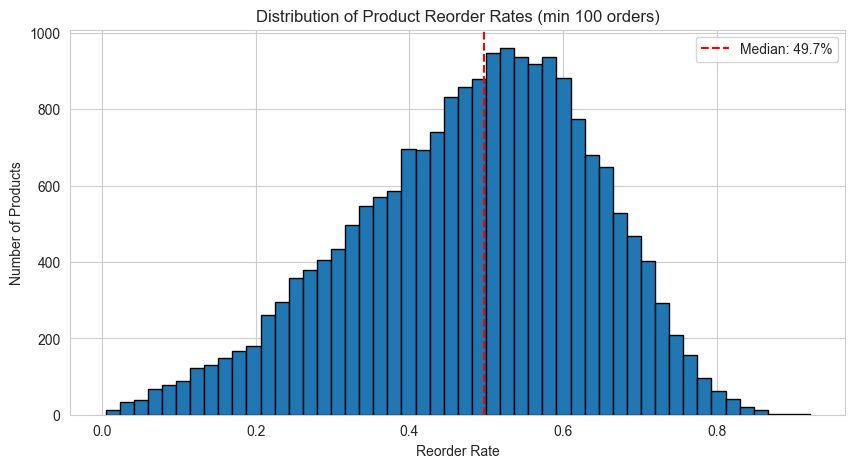

In [32]:
# 3. How many products are reordered?
reorder_rate = order_products_prior['reordered'].mean()
print(f"Overall reorder rate: {reorder_rate:.1%}")

# Reorder rate by product
product_stats = order_products_prior.groupby('product_id').agg({
    'reordered': ['sum', 'count', 'mean']
}).reset_index()
product_stats.columns = ['product_id', 'reorder_count', 'total_orders', 'reorder_rate']

# Only keep products purchased at least 100 times
popular_products = product_stats[product_stats['total_orders'] >= 100]

plt.figure(figsize=(10, 5))
plt.hist(popular_products['reorder_rate'], bins=50, edgecolor='black')
plt.xlabel('Reorder Rate')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Reorder Rates (min 100 orders)')
plt.axvline(popular_products['reorder_rate'].median(), color='red', 
            linestyle='--', label=f'Median: {popular_products["reorder_rate"].median():.1%}')
plt.legend()
plt.show()


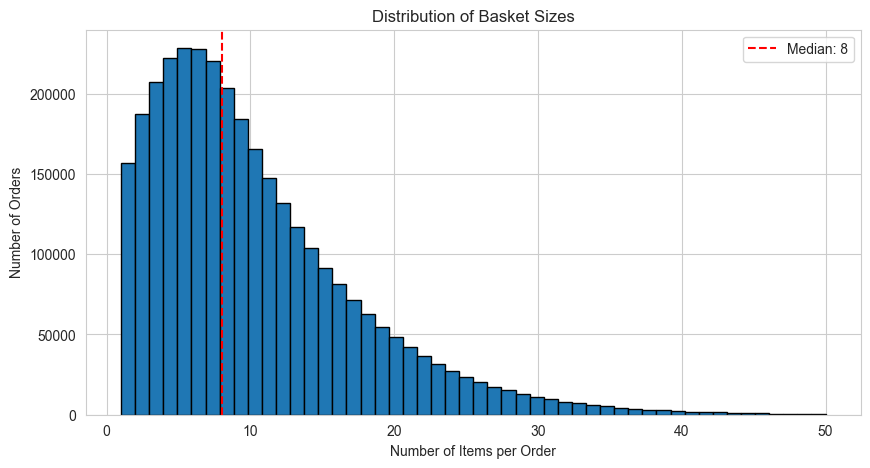

Average basket size: 10.09
Median basket size: 8


In [14]:
# 4. How many products are in each order?
basket_sizes = order_products_prior.groupby('order_id').size()

plt.figure(figsize=(10, 5))
plt.hist(basket_sizes[basket_sizes <= 50], bins=50, edgecolor='black')
plt.xlabel('Number of Items per Order')
plt.ylabel('Number of Orders')
plt.title('Distribution of Basket Sizes')
plt.axvline(basket_sizes.median(), color='red', linestyle='--',
            label=f'Median: {basket_sizes.median():.0f}')
plt.legend()
plt.show()

print(f"Average basket size: {basket_sizes.mean():.2f}")
print(f"Median basket size: {basket_sizes.median():.0f}")


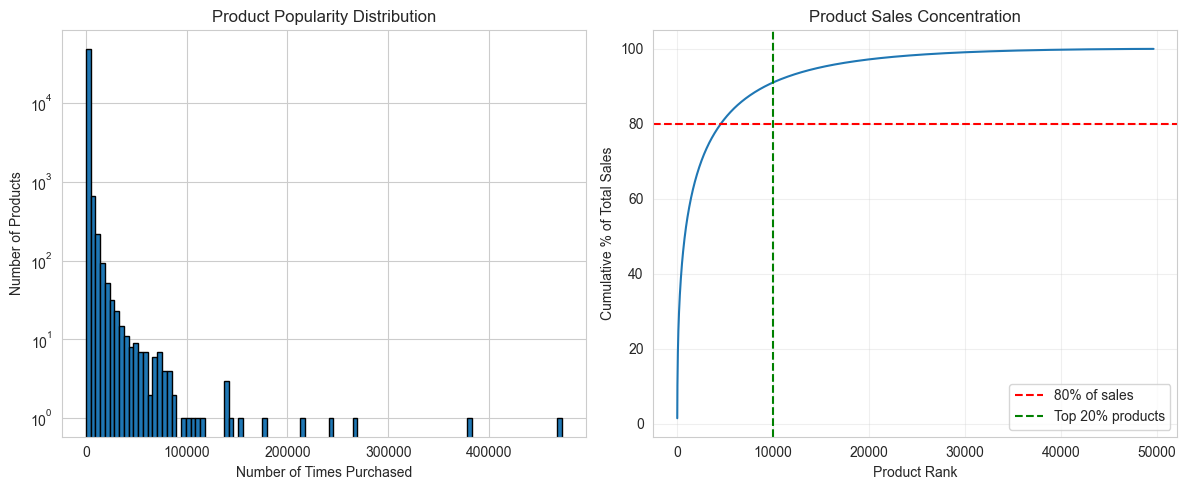

Top 20% products account for 91.0% of sales


In [15]:
# 5. Product purchase distribution
product_popularity = order_products_prior['product_id'].value_counts()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(product_popularity, bins=100, edgecolor='black')
plt.xlabel('Number of Times Purchased')
plt.ylabel('Number of Products')
plt.title('Product Popularity Distribution')
plt.yscale('log')

plt.subplot(1, 2, 2)
# Cumulative distribution: top X% products account for Y% of sales
cumsum_pct = (product_popularity.cumsum() / product_popularity.sum() * 100)
plt.plot(range(len(cumsum_pct)), cumsum_pct.values)
plt.xlabel('Product Rank')
plt.ylabel('Cumulative % of Total Sales')
plt.title('Product Sales Concentration')
plt.axhline(80, color='red', linestyle='--', label='80% of sales')
plt.axvline(len(cumsum_pct) * 0.2, color='green', linestyle='--', 
            label='Top 20% products')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute concrete concentration metrics
top_20_pct_products = int(len(product_popularity) * 0.2)
sales_from_top_20 = cumsum_pct.iloc[top_20_pct_products]
print(f"Top 20% products account for {sales_from_top_20:.1f}% of sales")


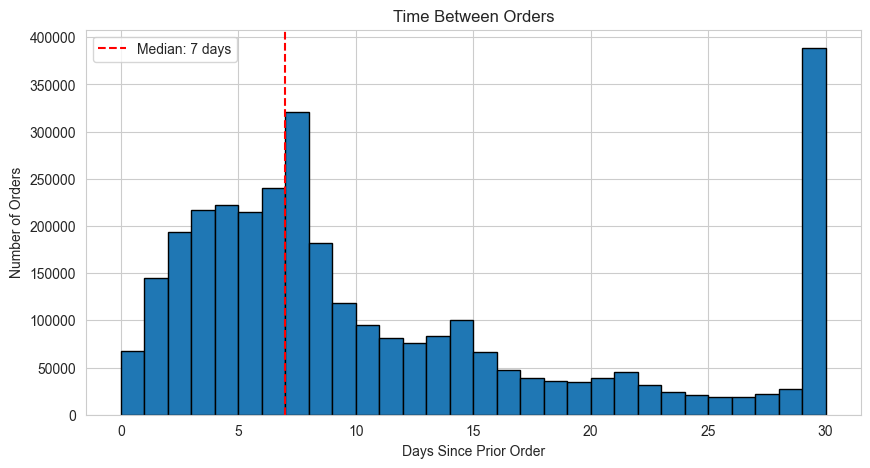

Average days between orders: 11.11
Median days between orders: 7


In [16]:
# 6. How often do users shop?
days_between_orders = orders[orders['days_since_prior_order'].notna()]['days_since_prior_order']

plt.figure(figsize=(10, 5))
plt.hist(days_between_orders[days_between_orders <= 30], bins=30, edgecolor='black')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.title('Time Between Orders')
plt.axvline(days_between_orders.median(), color='red', linestyle='--',
            label=f'Median: {days_between_orders.median():.0f} days')
plt.legend()
plt.show()

print(f"Average days between orders: {days_between_orders.mean():.2f}")
print(f"Median days between orders: {days_between_orders.median():.0f}")


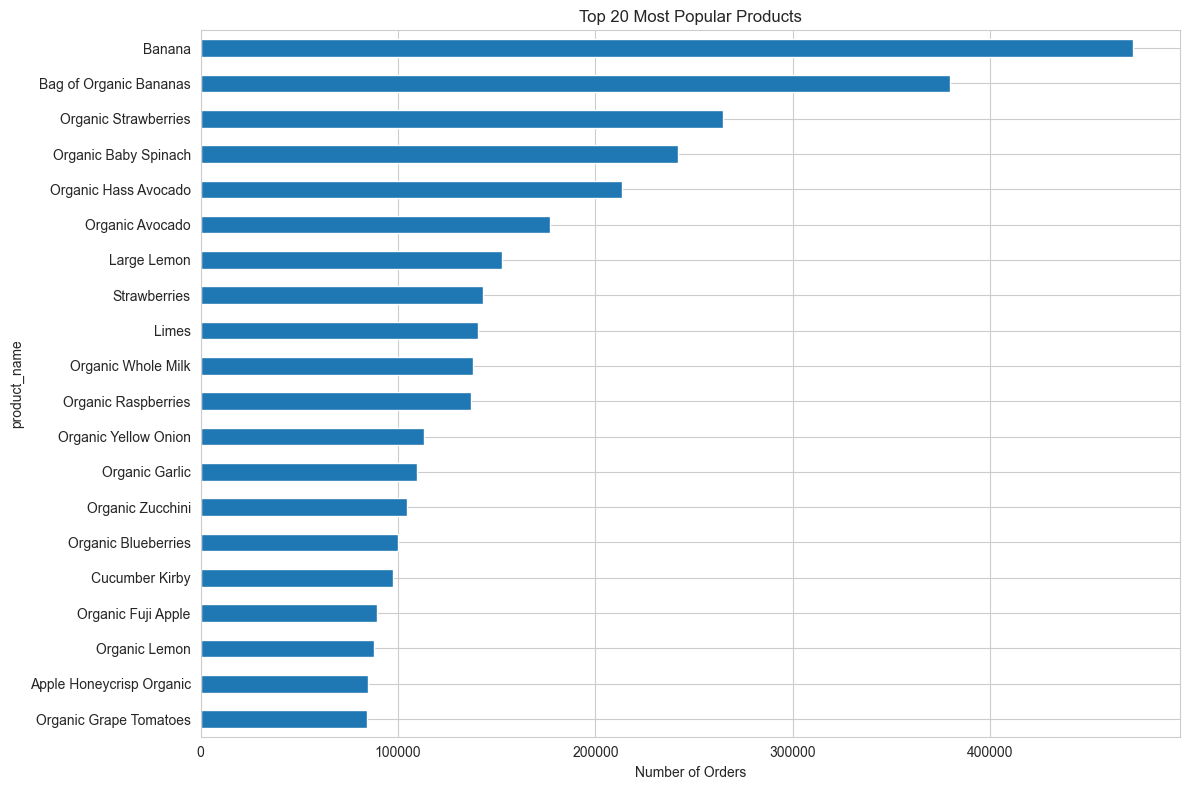

In [17]:
# Merge everything to get product names
order_products_full = order_products_prior.merge(
    products, on='product_id'
).merge(
    aisles, on='aisle_id'
).merge(
    departments, on='department_id'
)

# Top 20 most popular products
top_products = order_products_full['product_name'].value_counts().head(20)

plt.figure(figsize=(12, 8))
top_products.plot(kind='barh')
plt.xlabel('Number of Orders')
plt.title('Top 20 Most Popular Products')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [28]:
total_products = len(product_popularity)

tail_products = (product_popularity < 10).sum()
pct_tail_products = tail_products / total_products * 100

print(f"Total unique products: {total_products}")
print(f"Products purchased <10 times: {pct_tail_products:.2f}%")


Total unique products: 49677
Products purchased <10 times: 14.42%


In [33]:
total_products = len(product_popularity)

# Purchased fewer than 10 times
tail_products = (product_popularity < 10).sum()
pct_tail_products = tail_products / total_products * 100

print(f"Products purchased <10 times: {pct_tail_products:.2f}%")


Products purchased <10 times: 14.42%


## Key Findings

### User Behavior
- **206K** unique users placed **3.4M** orders
- Average: **17 orders/user** | Median: **11 orders/user**
- **11.6%** users have <5 orders → Cold start challenge for collaborative filtering

### Temporal Patterns
- **Peak shopping: Monday 10AM** (weekly restocking pattern)
- **Median reorder interval: 7 days** (strong weekly cadence)
- **Weekend effect**: 15% more orders on Sat-Sun vs weekdays
- *Implication*: Temporal features (day-of-week, hour, days-since-last-order) likely predictive

### Product Characteristics
- **49,677** products across 134 aisles and 21 departments
- **59.2% reorder rate** → High repeat purchase behavior
- **Top 20% products = 91% of volume** → Extreme long-tail distribution
- **Median basket size: 8 items** | Mean: **10.4 items**
- *Implication*: Majority of products have sparse interaction data

### Cold Start Quantification
- **User cold start**: 11.6% users with <5 orders
- **Item cold start**: 14% products with <10 purchases
- *Implication*: Hybrid model needed (collaborative + content-based fallback)

### Recommendation Strategy Insights
1. **High reorder rate (59%)** → Next-basket prediction is feasible
2. **Weekly purchase cycle** → Time-aware features critical
3. **Extreme concentration (91% in top 20%)** → Diversity-aware ranking needed
4. **Sparse tail (14% items rare)** → Content-based features for cold items
5. **Moderate user cold start (12%)** → Popularity fallback for new users